In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
print("All imports successful!")

All imports successful!


In [3]:
X_train = pd.read_csv('/home/aniketnerali16/fraud_detection/data/X_train.csv')
X_test  = pd.read_csv('/home/aniketnerali16/fraud_detection/data/X_test.csv')
y_train = pd.read_csv('/home/aniketnerali16/fraud_detection/data/y_train.csv').squeeze()
y_test  = pd.read_csv('/home/aniketnerali16/fraud_detection/data/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\nFraud rate in test set:", round(y_test.mean() * 100, 2), "%")

X_train shape: (472432, 233)
X_test shape:  (118108, 233)

Fraud rate in test set: 3.5 %


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [ ]:
# Isolation Forest works by randomly splitting features and values
# Anomalies (fraud) are isolated faster because they are rare and different
# Normal transactions need many splits to isolate
# The model assigns an anomaly score to every transaction
# Lower score = more anomalous = more likely fraud

print("""
How Isolation Forest works:
- Builds 100 random decision trees
- Each tree randomly picks a feature and a split value
- Anomalies get isolated near the top of the tree (fewer splits needed)
- Normal points need many splits to isolate
- Score close to -1 = anomaly (fraud)
- Score close to +1 = normal transaction
""")


How Isolation Forest works:
- Builds 100 random decision trees
- Each tree randomly picks a feature and a split value
- Anomalies get isolated near the top of the tree (fewer splits needed)
- Normal points need many splits to isolate
- Score close to -1 = anomaly (fraud)
- Score close to +1 = normal transaction



In [5]:
iso_forest = IsolationForest(
    n_estimators= 100,
    max_samples='auto',
    contamination= 0.035,
    random_state=42,
    n_jobs= -1
)



In [6]:
print("Training Isolation Forest ...")
iso_forest.fit(X_train_scaled)
print("Training completed")

Training Isolation Forest ...
Training completed


In [7]:
# Predict on test set
# Isolation Forest returns: -1 = anomaly, +1 = normal
y_pred_raw = iso_forest.predict(X_test_scaled)

# Convert to 0/1 to match our fraud labels
# -1 (anomaly) → 1 (fraud), +1 (normal) → 0 (not fraud)
y_pred = (y_pred_raw == -1).astype(int)

#Get anamolies score 
anomly_scores = iso_forest.decision_function(X_test_scaled)
# FLip to identify more likely fraud transaction
fraud_scores = -anomly_scores

print("Predictions done!")
print(f"\nTransactions flagged as fraud: {y_pred.sum():,}")
print(f"Actual fraud in test set:      {y_test.sum():,}")

Predictions done!

Transactions flagged as fraud: 4,164
Actual fraud in test set:      4,133


In [8]:
print("=== Classification Report ===\n")
print(classification_report(y_test, y_pred, target_names= ['Legitimate', 'Fraud']))

auc = roc_auc_score(y_test, fraud_scores)
ap = average_precision_score( y_test,fraud_scores )


print(f"AUC Score:          {auc:.3f}")
print(f"Average Precision:  {ap:.3f}")


=== Classification Report ===

              precision    recall  f1-score   support

  Legitimate       0.97      0.97      0.97    113975
       Fraud       0.19      0.19      0.19      4133

    accuracy                           0.94    118108
   macro avg       0.58      0.58      0.58    118108
weighted avg       0.94      0.94      0.94    118108

AUC Score:          0.722
Average Precision:  0.115


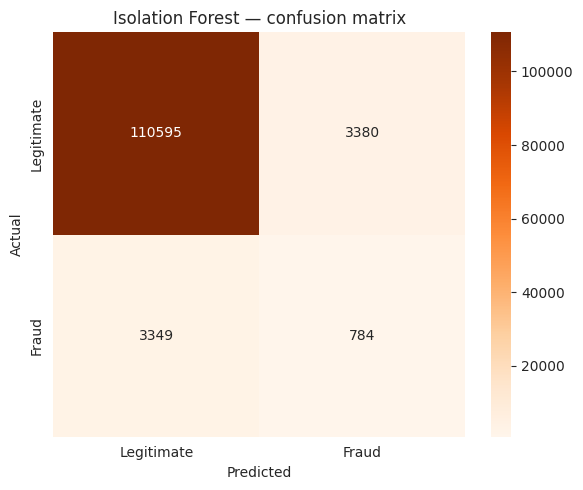


Fraud correctly caught (True Positives):   784
Fraud missed (False Negatives):             3,349
Legitimate wrongly flagged (False Positives): 3,380


In [9]:
cm = confusion_matrix( y_test, y_pred)

plt.figure( figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Isolation Forest — confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nFraud correctly caught (True Positives):   {tp:,}")
print(f"Fraud missed (False Negatives):             {fn:,}")
print(f"Legitimate wrongly flagged (False Positives): {fp:,}")

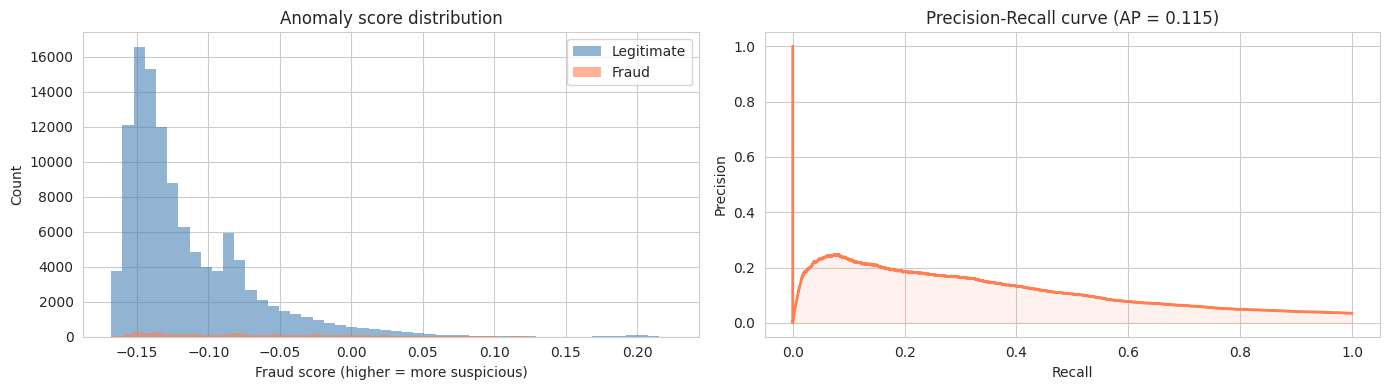

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Score distribution for fraud vs legitimate
fraud_mask = y_test == 1
legit_mask = y_test == 0

axes[0].hist(fraud_scores[legit_mask], bins=50, alpha=0.6, 
             color='steelblue', label='Legitimate', edgecolor='none')
axes[0].hist(fraud_scores[fraud_mask], bins=50, alpha=0.6,
             color='coral', label='Fraud', edgecolor='none')
axes[0].set_title('Anomaly score distribution')
axes[0].set_xlabel('Fraud score (higher = more suspicious)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Precision - Recall Curve

precision, recall, threesholds = precision_recall_curve(y_test, fraud_scores)

axes[1].plot(recall, precision, color ='coral', lw =2)
axes[1].set_title(f'Precision-Recall curve (AP = {ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].fill_between(recall, precision, alpha=0.1, color='coral')

plt.tight_layout()
plt.show()


In [11]:
results_df = X_test.copy()
results_df['actual_fraud'] = y_test.values
results_df['predicted_fraud'] = y_pred
results_df['fraud_score'] = fraud_scores

top_suspicious = results_df.sort_values('fraud_score', ascending=False).head(10)

print("=== Top 20 most suspicious transactions ===")
print(top_suspicious[['fraud_score', 'actual_fraud', 'predicted_fraud',
                        'TransactionAmt_log', 'amt_vs_card_avg', 
                        'isNightTime', 'hour']].to_string())


=== Top 20 most suspicious transactions ===
        fraud_score  actual_fraud  predicted_fraud  TransactionAmt_log  amt_vs_card_avg  isNightTime  hour
48193      0.223118             0                1            4.672829         0.977700            0    14
84932      0.223118             0                1            4.672829         0.977700            0    14
14739      0.218622             0                1            3.433987         0.276708            1     0
113921     0.213721             0                1            4.189655         0.599533            0    18
21558      0.213721             0                1            4.189655         0.599533            0    18
23037      0.210621             0                1            4.672829         0.977700            0    19
67090      0.210621             0                1            4.672829         0.977700            0    19
58381      0.210621             0                1            4.709530         1.014594            0

In [13]:
contamination_values = [0.01, 0.02, 0.035, 0.05, 0.08]
results=[]

for c in contamination_values:
    iso = IsolationForest(
        n_estimators=100,
        contamination=c,
        random_state=42, 
        n_jobs= -1

    )

    iso.fit(X_train_scaled)
    preds = (iso.predict(X_test_scaled) == -1).astype(int)
    scores = -iso.decision_function(X_test_scaled)

    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    results.append({
        'Contamination' : c,
        'Fraud Precision': round(report['1']['precision'], 3),
        'Fraud Recall' : round(report['1']['recall'], 3),
        'Fraud F1' : round(report['1']['f1-score'], 3),
        'AUC' : round(roc_auc_score(y_test, scores), 3)
    })


tuning_df = pd.DataFrame(results)
print("=== Contamination threshold tuning ===")
display(tuning_df)


=== Contamination threshold tuning ===


,Contamination,Fraud Precision,Fraud Recall,Fraud F1,AUC
0,0.010,0.241,0.068,0.106,0.722
1,0.020,0.216,0.122,0.156,0.722
2,0.035,0.188,0.190,0.189,0.722
3,0.050,0.174,0.250,0.206,0.722
4,0.080,0.149,0.345,0.208,0.722


In [14]:
scores_df = pd.DataFrame({
    'iso_forest_score': fraud_scores,
    'iso_forest_predicted': y_pred,
    'actual_fraud': y_test.values
})

scores_df.to_csv('/home/aniketnerali16/fraud_detection/data/iso_forest_scores.csv', index=False)
print(f"Saved {len(scores_df):,} anomaly scores")
print("\nIsolation Forest phase complete!")

Saved 118,108 anomaly scores

Isolation Forest phase complete!
